In [1]:
from autograd.core.engine import Value
from autograd.core.ui import show

#### Example: deep dive into handling gradient by hand

In [2]:
a = Value(-2.0, label='a')
b = Value(3.0, label='b')
c = a * b; c.label = 'c'
d = Value(-1.5, label='d')
e = c + d; e.label = 'e'
f = Value(-2.0, label='f')
L = e * f; L.label = 'L'
L

Value(L | data=15.0 | grad=0.0)

In [3]:
# Q: dL/dL = ?
# dL/dL = ((L + h) - L) / h
# dL/dL = (h) / h
# A: dL/dL = 1

L.grad = 1.0

In [4]:
# Q: dL/de = ?
# e * f = L
# dL/de = (((e + h) * f) - (e * f)) / h
# dL/de = (e*f + f*h - e*f) / h
# dL/de = (f*h) / h
# A: dL/de = f

e.grad = f.data
f.grad = e.data

In [5]:
# Q: dL/dc = ?
# c + d = e
# de/dc = 1.0
# de/dd = 1.0

# By chain rule:
# dL/dc = de/dc * dL/de
# dL/dc = 1.0 * f
c.grad = 1.0 * e.grad

# dL/dd = de/dd * dL/de
# dL/dd = 1.0 * f
d.grad = 1.0 * e.grad

In [6]:
# Q: dL/da = dc/da * de/dc * dL/de * dL/dL = ?
# a * b = c
# dc/da = b
# dc/db = a

# By chain rule:
# dL/da = b * c.grad
# dL/db = a * c.grad
a.grad = b.data * c.grad
b.grad = a.data * c.grad

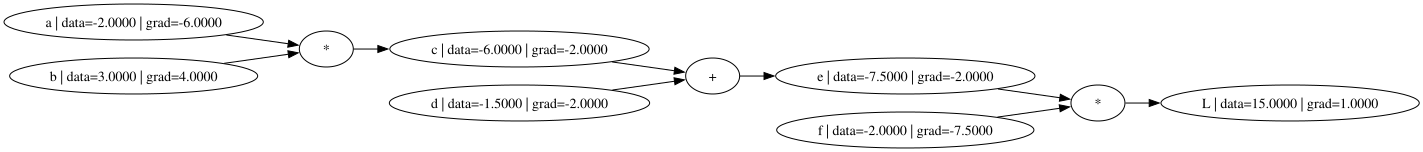

In [7]:
show(L)

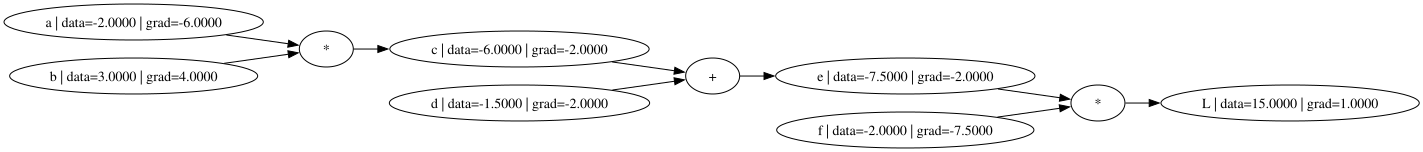

In [8]:
a = Value(-2.0, label='a')
b = Value(3.0, label='b')
c = a * b; c.label = 'c'
d = Value(-1.5, label='d')
e = c + d; e.label = 'e'
f = Value(-2.0, label='f')
L = e * f; L.label = 'L'

L.backward()
show(L)

#### Example: issue in case without cumulative gradient 

In [9]:
# Q: dy/dx = ?
# x + x = y
# 2x = y
# A: dy/dx = 1 + 1 = 2

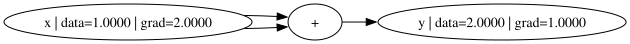

In [10]:
x = Value(1.0, label='x')
y = x + x; y.label = 'y'

y.backward()
show(y)

#### Debug tool: compute gradients by tweaking target variable

In [11]:
def compute_grad(L, variable, h=1e-6):
    visited = set()
    def find(node):
        if node is None or node in visited:
            return None
        visited.add(node)
        if node.label == variable:
            return node
        for p in node._parents:
            if (target := find(p)) is not None:
                return target
        return None

    target = find(L)

    f1 = L.compute()
    f2 = L.compute(override_node=target, override_delta=+h)
    
    return (f2 - f1) / h

compute_grad(x, variable='x')

0.9999999999177334